<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day11-rnns-lstm-gru-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 11 — Sequences, language models and SignalP, in code {.unnumbered}

Three parts, following the book page:

1. **Recurrent networks.** Why gradients vanish through time, the LSTM
   cell written out by hand, and per-residue signal-peptide labelling
   with a sliding window, a simple RNN, an LSTM and a bidirectional LSTM.
2. **Language models.** A tiny next-residue language model, attention
   from scratch, the causal mask that turns BERT into GPT, and a real
   protein language model (ESM-2) filling in masked residues.
3. **SignalP 6.0's idea, at classroom scale.** Signal-peptide detection
   from one-hot sequences vs. from frozen ESM-2 embeddings: overall, with
   very few training examples, and as a function of how similar a test
   protein is to the training set.

**Data.** 4,910 reviewed UniProt proteins from eukaryotes and bacteria:
1,936 with an *experimentally supported* signal peptide (evidence
ECO:0000269, so we are not learning SignalP's own predictions back),
1,988 cytoplasmic or nuclear proteins and 986 transmembrane proteins
without a signal peptide (hard negatives: a transmembrane helix is also a
hydrophobic stretch). The file is hosted in the course repository; set
`FETCH_LIVE = True` to rebuild it from UniProt instead.

**Runtime.** A few minutes on a CPU. Part 3 downloads ESM-2 (35M
parameters, ~140 MB); on Colab run `!pip install fair-esm` first.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
import torch.nn.functional as F
import os, io, re, shutil, subprocess, tempfile
import requests
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, matthews_corrcoef,
                             roc_auc_score, average_precision_score, precision_recall_curve)
device = "cuda" if torch.cuda.is_available() else "cpu"
FIGS = "../figs" if os.path.isdir("../figs") else "."
REPO = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/"
def course_file(name):
    '''Read a data file from the local repository if present, else from GitHub.'''
    local = os.path.join("data", name)
    return open(local).read() if os.path.exists(local) else requests.get(REPO + name, timeout=60).text

# Part 1 — Recurrent networks

## 1) Why gradients vanish or explode through many steps

Backpropagation through $k$ time steps multiplies by (roughly) the same recurrent weight $k$ times. If that factor's magnitude is below 1, the product shrinks toward zero (vanishing); if above 1, it blows up (exploding) — this is the same "eigenvalue of the recurrence" framing Ekman's Chapter 9 slides use.

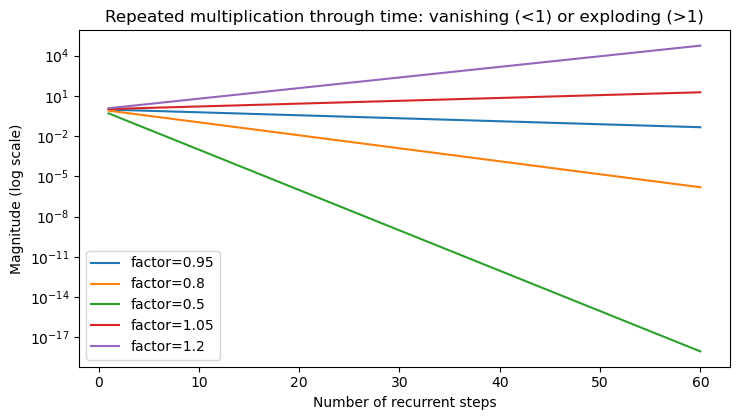

In [2]:
depth = np.arange(1, 61)
plt.figure(figsize=(7.5, 4.3))
for factor in [0.95, 0.8, 0.5, 1.05, 1.2]:
    plt.plot(depth, factor ** depth, label=f"factor={factor}")
plt.yscale("log")
plt.xlabel("Number of recurrent steps")
plt.ylabel("Magnitude (log scale)")
plt.title("Repeated multiplication through time: vanishing (<1) or exploding (>1)")
plt.legend()
plt.tight_layout()
plt.savefig("../figs/day11-vanishing-exploding.png", dpi=130)
plt.show()

Concretely: at factor 0.8, after 60 steps the signal is $0.8^{60} \approx$

In [3]:
print(f"{0.8**60:.2e}")
print(f"{1.2**60:.2e}")

1.53e-06
5.63e+04


## 2) LSTM: gates and the Constant Error Carousel

A plain RNN's hidden state is overwritten every step, which is exactly why the multiplicative decay above happens. An LSTM instead keeps a separate **cell state** $c_t$ that gates control additively: a **forget gate** $f_t$ decides how much of the old cell state to keep, an **input gate** $i_t$ decides how much of a new candidate value $\tilde c_t$ to add, and an **output gate** $o_t$ decides how much of the cell state to expose as the hidden state:

$$
f_t = \sigma(W_f[h_{t-1}, x_t]), \quad i_t = \sigma(W_i[h_{t-1}, x_t]), \quad \tilde c_t = \tanh(W_c[h_{t-1}, x_t])
$$
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t, \qquad o_t = \sigma(W_o[h_{t-1}, x_t]), \qquad h_t = o_t \odot \tanh(c_t)
$$

When $f_t \approx 1$ and $i_t \approx 0$, $c_t \approx c_{t-1}$ — the cell state is carried forward almost unchanged, sidestepping the repeated-multiplication decay above. This is why LSTM's forget-gate bias is conventionally initialized to $+1$ (favoring "remember" at the start of training, adapted from `ch10.ipynb`'s `ExplicitLSTMCell`).

In [4]:
class ExplicitLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        in_dim = input_size + hidden_size
        self.Wf = nn.Linear(in_dim, hidden_size)
        self.Wi = nn.Linear(in_dim, hidden_size)
        self.Wc = nn.Linear(in_dim, hidden_size)
        self.Wo = nn.Linear(in_dim, hidden_size)
        with torch.no_grad():
            self.Wf.bias.fill_(1.0)  # forget-gate bias init to 1

    def forward(self, x_t, h_prev, c_prev):
        z = torch.cat([h_prev, x_t], dim=1)
        f_t = torch.sigmoid(self.Wf(z))
        i_t = torch.sigmoid(self.Wi(z))
        c_tilde = torch.tanh(self.Wc(z))
        c_t = f_t * c_prev + i_t * c_tilde
        o_t = torch.sigmoid(self.Wo(z))
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t

torch.manual_seed(0)
cell = ExplicitLSTMCell(input_size=4, hidden_size=3)
x_t = torch.randn(1, 4)
h0 = torch.zeros(1, 3)
c0 = torch.zeros(1, 3)
h1, c1 = cell(x_t, h0, c0)
print("h1:", h1.detach().numpy().round(4))
print("c1:", c1.detach().numpy().round(4))

# cross-check against PyTorch's own nn.LSTMCell with the same weights.
# ExplicitLSTMCell concatenates z = [h_prev, x_t] before each Linear, so a
# gate's weight columns [0:hidden_size] act on h_prev and [hidden_size:] act
# on x_t -- the opposite split/order from nn.LSTMCell's separate weight_ih
# (acts on x_t) / weight_hh (acts on h_prev). nn.LSTMCell packs gates in
# order i, f, g, o.
hidden_size = 3
ref = nn.LSTMCell(4, hidden_size)
with torch.no_grad():
    W_ih = torch.cat([cell.Wi.weight[:, hidden_size:], cell.Wf.weight[:, hidden_size:], cell.Wc.weight[:, hidden_size:], cell.Wo.weight[:, hidden_size:]], dim=0)
    W_hh = torch.cat([cell.Wi.weight[:, :hidden_size], cell.Wf.weight[:, :hidden_size], cell.Wc.weight[:, :hidden_size], cell.Wo.weight[:, :hidden_size]], dim=0)
    b_ih = torch.cat([cell.Wi.bias, cell.Wf.bias, cell.Wc.bias, cell.Wo.bias])
    ref.weight_ih.copy_(W_ih)
    ref.weight_hh.copy_(W_hh)
    ref.bias_ih.copy_(b_ih)
    ref.bias_hh.zero_()
h1_ref, c1_ref = ref(x_t, (h0, c0))
print("max abs diff h:", (h1 - h1_ref).abs().max().item())
print("max abs diff c:", (c1 - c1_ref).abs().max().item())

h1: [[ 0.1534 -0.1484 -0.0556]]
c1: [[ 0.2277 -0.2663 -0.1956]]
max abs diff h: 0.0
max abs diff c: 0.0


## 3) Bidirectional LSTM and GRU

Two real refinements on top of plain LSTM, both used below on the real SignalP case study:

- **Bidirectional (BiLSTM)**: runs one LSTM left-to-right and a second right-to-left over the same sequence, concatenating their hidden states at each position. Whether a residue is part of a signal peptide depends on context from *both* directions (e.g. the h-region's hydrophobic stretch is defined relative to residues on both sides) — a plain, forward-only LSTM can only see what came before.
- **GRU (Gated Recurrent Unit)**: merges LSTM's three gates into two (a reset gate and an update gate) and drops the separate cell state, folding everything into a single hidden state. Fewer parameters, often comparably good in practice — this is a real empirical question the case study below answers on real data rather than asserting one architecture is "better."

## Case study: labelling signal-peptide residues

Load the dataset, and give every residue of the first 70 a label: 1
inside the annotated signal peptide, 0 elsewhere.

In [5]:
FETCH_LIVE = False
if FETCH_LIVE:
    raise NotImplementedError("See the book page: the dataset was built from three UniProt queries per domain "
                              "(experimental signal peptides; cytoplasm/nucleus; transmembrane without signal "
                              "peptide). Rebuilding takes several minutes of paging through the UniProt REST API.")
table = pd.read_csv(io.StringIO(course_file("day11-signal-peptides.tsv")), sep="\t", dtype={"sp_start": "Int64", "sp_end": "Int64"})
sequences = table.sequence.tolist()
has_sp = table.sp_end.notna().to_numpy().astype(int)
print(table.group.value_counts().to_string())
print(f"\n{len(table)} proteins, {has_sp.sum()} with an experimentally supported signal peptide; "
      f"signal-peptide length median {int(table.sp_end.median())}, max {int(table.sp_end.max())}")

NTERM_LEN = 70
labels = []
for seq, end in zip(sequences, table.sp_end):
    lab = np.zeros(len(seq), dtype=np.int64)
    if pd.notna(end):
        lab[:int(end)] = 1
    labels.append(lab)

group
euk_sp     1158
euk_cyt     997
bac_cyt     991
bac_sp      778
bac_tm      496
euk_tm      490

4910 proteins, 1936 with an experimentally supported signal peptide; signal-peptide length median 23, max 57


**Homology-aware split (Day 8).** Proteins are clustered at 30% identity
with MMseqs2 (precomputed file if `mmseqs` is not installed), and whole
clusters go to training, validation or test.

In [6]:
if shutil.which("mmseqs"):
    tmp = tempfile.mkdtemp()
    with open(f"{tmp}/in.fasta", "w") as f:
        for a, s in zip(table.accession, sequences):
            f.write(f">{a}\n{s}\n")
    subprocess.run(["mmseqs", "easy-cluster", f"{tmp}/in.fasta", f"{tmp}/clu", f"{tmp}/w", "--min-seq-id", "0.3",
                    "-c", "0.5", "-v", "1"], check=True, stdout=subprocess.DEVNULL)
    pairs = [l.split("\t") for l in open(f"{tmp}/clu_cluster.tsv").read().split("\n") if l]
    shutil.rmtree(tmp)
    print("clustered with local MMseqs2")
else:
    pairs = [l.split("\t") for l in course_file("day11-signal-peptides-mmseqs-30.tsv").strip().split("\n")[1:]]
    print("loaded the precomputed MMseqs2 clustering")
member_to_rep = {m: r for r, m in pairs}
reps = [member_to_rep.get(a, a) for a in table.accession]
rep_id = {r: i for i, r in enumerate(sorted(set(reps)))}
groups = np.array([rep_id[r] for r in reps])
print(f"{len(table)} proteins in {len(rep_id)} clusters")

def homology_split(y, groups, fractions=(0.70, 0.15, 0.15), seed=0):
    '''Assign whole clusters, in random order, to train/val/test: each cluster
    goes to the split furthest below its target share of that cluster's
    classes (ties broken at random). Returns three index arrays.'''
    rng = np.random.RandomState(seed)
    n_classes = y.max() + 1
    target = np.outer(fractions, np.bincount(y, minlength=n_classes))   # (3 splits, n_classes)
    have = np.zeros_like(target)
    assignment = {}
    for g in rng.permutation(np.unique(groups)):
        cls_counts = np.bincount(y[groups == g], minlength=n_classes)
        deficit = ((target - have) * (cls_counts > 0)).sum(axis=1) / target.sum(axis=1)
        best = np.flatnonzero(deficit == deficit.max())
        split = int(rng.choice(best))
        assignment[g] = split
        have[split] += cls_counts
    split_of = np.array([assignment[g] for g in groups])
    return [np.where(split_of == k)[0] for k in range(3)]

tr_i, va_i, te_i = homology_split(has_sp, groups)
print(f"train {len(tr_i)} / val {len(va_i)} / test {len(te_i)} proteins; "
      f"signal-peptide fraction {has_sp[tr_i].mean():.2f} / {has_sp[va_i].mean():.2f} / {has_sp[te_i].mean():.2f}")
seq_train, lab_train = [sequences[i] for i in tr_i], [labels[i] for i in tr_i]
seq_val, lab_val = [sequences[i] for i in va_i], [labels[i] for i in va_i]
seq_test, lab_test = [sequences[i] for i in te_i], [labels[i] for i in te_i]

clustered with local MMseqs2
4910 proteins in 3205 clusters
train 3432 / val 737 / test 741 proteins; signal-peptide fraction 0.39 / 0.39 / 0.40


### Baseline: a sliding window

Day 5 and Day 6 style: each residue is classified from a 15-residue
window around it, one-hot encoded, with a linear classifier.

In [7]:
WINDOW = 15
AA = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {a: i for i, a in enumerate(AA)}
UNK_IDX = len(AA)
VOCAB_SIZE = len(AA) + 1

def aa_index(ch):
    return aa_to_idx.get(ch, UNK_IDX)

def make_residue_examples(seq_list, lab_list, nterm_len=70, window=15):
    r = window // 2
    X_idx, y = [], []
    for seq, yseq in zip(seq_list, lab_list):
        L = min(len(seq), nterm_len)
        for pos in range(L):
            w = [aa_index(seq[j]) if 0 <= j < L else UNK_IDX for j in range(pos - r, pos + r + 1)]
            X_idx.append(w)
            y.append(int(yseq[pos]))
    return np.array(X_idx, dtype=np.int64), np.array(y, dtype=np.int64)

def one_hot_flat(X_idx, vocab_size):
    n, w = X_idx.shape
    out = np.zeros((n, w * vocab_size), dtype=np.float32)
    for i in range(n):
        for p in range(w):
            out[i, p * vocab_size + X_idx[i, p]] = 1.0
    return out

Xtr_idx, ytr = make_residue_examples(seq_train, lab_train, NTERM_LEN, WINDOW)
Xte_idx, yte = make_residue_examples(seq_test, lab_test, NTERM_LEN, WINDOW)
print("Sliding-window residue samples train/test:", Xtr_idx.shape, Xte_idx.shape)
print("Positive rate train/test:", ytr.mean().round(4), yte.mean().round(4))

Xtr = one_hot_flat(Xtr_idx, VOCAB_SIZE)
Xte = one_hot_flat(Xte_idx, VOCAB_SIZE)

clf = SGDClassifier(loss="log_loss", alpha=1e-4, class_weight="balanced", max_iter=50, random_state=0)
clf.fit(Xtr, ytr)
proba_sw = clf.predict_proba(Xte)[:, 1]
pred_sw = (proba_sw >= 0.5).astype(np.int64)
metrics_sw = {
    "precision": precision_score(yte, pred_sw, zero_division=0),
    "recall": recall_score(yte, pred_sw, zero_division=0),
    "f1": f1_score(yte, pred_sw, zero_division=0),
    "mcc": matthews_corrcoef(yte, pred_sw),
    "auroc": roc_auc_score(yte, proba_sw),
    "aupr": average_precision_score(yte, proba_sw),
}
print("Sliding-window baseline:", {k: round(v, 4) for k, v in metrics_sw.items()})

Sliding-window residue samples train/test: (240240, 15) (51870, 15)
Positive rate train/test: 0.1382 0.1358


Sliding-window baseline: {'precision': 0.4373, 'recall': 0.8774, 'f1': 0.5837, 'mcc': 0.5386, 'auroc': 0.926, 'aupr': 0.6812}


### Recurrent taggers: simple RNN, LSTM, bidirectional LSTM

One model class, switched by `kind`. Each reads the 70 N-terminal
residues and outputs a signal-peptide probability for every residue. The
validation set is printed during training; the test set is used once, at
the end.

In [8]:
def encode_protein_batch(seq_list, lab_list, nterm_len=70):
    X = np.full((len(seq_list), nterm_len), UNK_IDX, dtype=np.int64)
    Y = np.zeros((len(seq_list), nterm_len), dtype=np.float32)
    M = np.zeros((len(seq_list), nterm_len), dtype=np.float32)
    for i, (seq, yseq) in enumerate(zip(seq_list, lab_list)):
        L = min(len(seq), nterm_len)
        for j in range(L):
            X[i, j] = aa_index(seq[j])
            Y[i, j] = float(yseq[j])
            M[i, j] = 1.0
    return X, Y, M

X_train_seq, y_train_seq, m_train_seq = encode_protein_batch(seq_train, lab_train, NTERM_LEN)
X_test_seq, y_test_seq, m_test_seq = encode_protein_batch(seq_test, lab_test, NTERM_LEN)

train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq), torch.from_numpy(m_train_seq))
test_ds = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(y_test_seq), torch.from_numpy(m_test_seq))
X_val_seq, y_val_seq, m_val_seq = encode_protein_batch(seq_val, lab_val, NTERM_LEN)
val_ds = TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(y_val_seq), torch.from_numpy(m_val_seq))
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)


class SeqTagger(nn.Module):
    """kind in {"rnn", "lstm", "bilstm", "gru"}."""
    def __init__(self, vocab_size, emb_dim=24, hid_dim=48, kind="rnn"):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        bidirectional = (kind == "bilstm")
        if kind in ("lstm", "bilstm"):
            self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True, bidirectional=bidirectional)
        elif kind == "gru":
            self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(emb_dim, hid_dim, batch_first=True, nonlinearity="tanh")
        out_dim = hid_dim * (2 if bidirectional else 1)
        self.out = nn.Linear(out_dim, 1)

    def forward(self, x):
        z = self.emb(x)
        h, _ = self.rnn(z)
        return self.out(h).squeeze(-1)


def n_params(model):
    return sum(p.numel() for p in model.parameters())


def train_sequence_model(model, train_loader, test_loader, epochs=6, lr=1e-3, val_loader=None):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    def run_eval(loader):
        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for xb, yb, mb in loader:
                xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
                probs = torch.sigmoid(model(xb))
                keep = mb > 0
                all_p.append(probs[keep].detach().cpu().numpy())
                all_y.append(yb[keep].detach().cpu().numpy())
        p = np.concatenate(all_p).astype(np.float32)
        y = np.concatenate(all_y).astype(np.int64)
        pred = (p >= 0.5).astype(np.int64)
        return {
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "mcc": matthews_corrcoef(y, pred),
            "auroc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
            "aupr": average_precision_score(y, p),
            "y": y, "proba": p,
        }

    for ep in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb, mb in train_loader:
            xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss_all = nn.functional.binary_cross_entropy_with_logits(logits, yb, reduction="none")
            loss = (loss_all * mb).sum() / mb.sum().clamp_min(1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            losses.append(float(loss.item()))
        val = run_eval(val_loader)
        print(f"  epoch {ep:02d} | loss {np.mean(losses):.4f} | val f1 {val['f1']:.4f} | val aupr {val['aupr']:.4f}")
    return run_eval(test_loader)


results = {"SlidingWindow": {**metrics_sw, "y": yte, "proba": proba_sw}}
param_counts = {}
torch.manual_seed(0)
for kind, name in [("rnn", "SimpleRNN"), ("lstm", "LSTM"), ("bilstm", "BiLSTM")]:
    print(f"Training {name}...")
    model = SeqTagger(VOCAB_SIZE, kind=kind)
    param_counts[name] = n_params(model)
    results[name] = train_sequence_model(model, train_loader, test_loader, epochs=8, lr=1e-3, val_loader=val_loader)

print()
print("Parameter counts:", param_counts)

Training SimpleRNN...


  epoch 01 | loss 0.4356 | val f1 0.1766 | val aupr 0.4233


  epoch 02 | loss 0.2838 | val f1 0.5569 | val aupr 0.6093


  epoch 03 | loss 0.2369 | val f1 0.5860 | val aupr 0.6478


  epoch 04 | loss 0.2204 | val f1 0.5856 | val aupr 0.6585


...

  epoch 04 | loss 0.1666 | val f1 0.7254 | val aupr 0.7602


  epoch 05 | loss 0.1522 | val f1 0.7559 | val aupr 0.7974


  epoch 06 | loss 0.1392 | val f1 0.7728 | val aupr 0.8549


  epoch 07 | loss 0.1276 | val f1 0.7972 | val aupr 0.8686


  epoch 08 | loss 0.1136 | val f1 0.7904 | val aupr 0.8859

Parameter counts: {'SimpleRNN': 4105, 'LSTM': 14761, 'BiLSTM': 29017}


Final test metrics

[SlidingWindow]
  precision: 0.4373
     recall: 0.8774
         f1: 0.5837
        mcc: 0.5386
       aupr: 0.6812
      auroc: 0.9260

[SimpleRNN]  (4,105 params)
  precision: 0.7442
     recall: 0.5954
         f1: 0.6616
        mcc: 0.6201
       aupr: 0.7702
      auroc: 0.9542

[LSTM]  (14,761 params)
  precision: 0.7452
     recall: 0.6125
         f1: 0.6723
        mcc: 0.6305
       aupr: 0.7669
      auroc: 0.9567

[BiLSTM]  (29,017 params)
  precision: 0.9112
     recall: 0.7783
         f1: 0.8395
        mcc: 0.8199
       aupr: 0.9198
      auroc: 0.9809


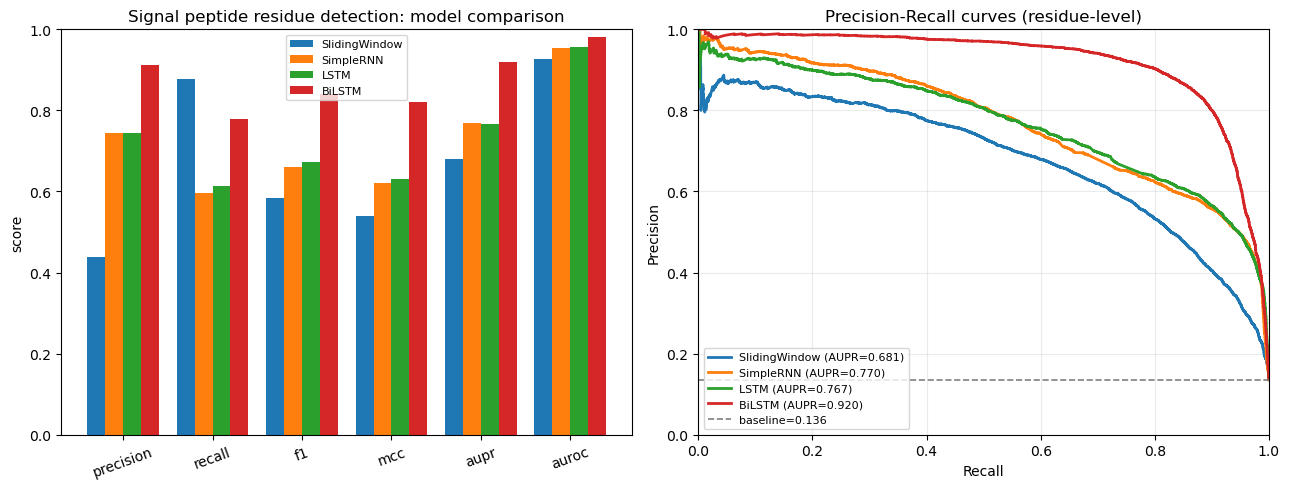

In [9]:
metric_names = ["precision", "recall", "f1", "mcc", "aupr", "auroc"]
model_names = list(results.keys())

print("Final test metrics")
for name in model_names:
    print(f"\n[{name}]" + (f"  ({param_counts[name]:,} params)" if name in param_counts else ""))
    for m in metric_names:
        print(f"  {m:>9s}: {results[name][m]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(metric_names))
w = 0.2
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metric_names]
    axes[0].bar(x + (i - 1.5) * w, vals, width=w, label=name)
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names, rotation=20)
axes[0].set_ylim(0, 1.0); axes[0].set_ylabel("score")
axes[0].set_title("Signal peptide residue detection: model comparison")
axes[0].legend(fontsize=8)

for name in model_names:
    y_true, p = results[name]["y"], results[name]["proba"]
    pr, rc, _ = precision_recall_curve(y_true, p)
    ap = average_precision_score(y_true, p)
    axes[1].plot(rc, pr, linewidth=2, label=f"{name} (AUPR={ap:.3f})")
baseline = np.mean(results["SlidingWindow"]["y"])
axes[1].axhline(baseline, linestyle="--", color="gray", linewidth=1.2, label=f"baseline={baseline:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (residue-level)")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].legend(loc="lower left", fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../figs/day11-model-comparison.png", dpi=130)
plt.show()

Reading the sequence in both directions helps: whether residue *i* is
still part of the signal peptide depends on what comes *after* it (the
cleavage site), which a forward-only network cannot see yet. SignalP 5.0
(2019) was built from exactly these parts: convolutions, a bidirectional
LSTM, and a conditional random field (CRF) on top that only allows valid
label orders (signal peptide first, then a single cleavage site, then
mature protein).

# Part 2 — Language models

## A tiny protein language model: predict the next residue

A **language model** assigns probabilities to sequences, one token at a
time. Trained only on unlabelled sequences, it has to learn the
regularities of the language. Here: an LSTM that reads a protein and
predicts each next residue, trained on the training-set proteins (first
120 residues). We compare its cross-entropy, in bits per residue, with a
model that only knows the average amino-acid composition.

In [10]:
LM_LEN = 120
def lm_batch(seqs):
    X = np.full((len(seqs), LM_LEN), UNK_IDX, dtype=np.int64)
    for i, s in enumerate(seqs):
        for j, ch in enumerate(s[:LM_LEN]):
            X[i, j] = aa_index(ch)
    return torch.tensor(X)

lm_train, lm_test = lm_batch(seq_train), lm_batch(seq_test)
comp = np.bincount(lm_train[lm_train < UNK_IDX].numpy(), minlength=VOCAB_SIZE)[:20] + 1
comp = comp / comp.sum()
mask_te = lm_test[:, 1:] < UNK_IDX
unigram_bits = -np.log2(comp[lm_test[:, 1:][mask_te].numpy()]).mean()

class ResidueLM(nn.Module):
    def __init__(self, emb=32, hid=128):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, emb)
        self.lstm = nn.LSTM(emb, hid, batch_first=True)
        self.out = nn.Linear(hid, VOCAB_SIZE)
    def forward(self, x):
        return self.out(self.lstm(self.emb(x))[0])

torch.manual_seed(0)
lm = ResidueLM().to(device)
opt = torch.optim.Adam(lm.parameters(), lr=3e-3)
def lm_loss(model, X):
    logits = model(X[:, :-1].to(device))
    target = X[:, 1:].to(device)
    keep = target < UNK_IDX
    return nn.functional.cross_entropy(logits[keep], target[keep])
for epoch in range(15):
    lm.train()
    for b in torch.randperm(len(lm_train)).split(64):
        opt.zero_grad(); lm_loss(lm, lm_train[b]).backward(); opt.step()
lm.eval()
with torch.no_grad():
    lstm_bits = lm_loss(lm, lm_test).item() / np.log(2)
print(f"uniform over 20 amino acids: {np.log2(20):.3f} bits per residue")
print(f"composition only:            {unigram_bits:.3f} bits per residue")
print(f"LSTM language model:         {lstm_bits:.3f} bits per residue (test proteins)")

uniform over 20 amino acids: 4.322 bits per residue
composition only:            4.164 bits per residue
LSTM language model:         4.071 bits per residue (test proteins)


The LSTM beats the composition model, but only by a little. Protein
sequences are hard to predict residue by residue, far harder than
English text. Large protein language models get much further by being
trained on hundreds of millions of sequences, and by using attention
instead of a single recurrent state.

## Attention from scratch

## 2) Self-attention from scratch: query, key, value

Attention answers a search-like question for every position in a sequence: "which other positions should I pay attention to, and how much?" Concretely, each position's embedding is projected into three vectors:

- **Query** ($Q$): what this position is looking for
- **Key** ($K$): what this position offers, for others to search against
- **Value** ($V$): what this position actually contributes if attended to

The attention weights are a softmax over scaled dot products of queries against keys; the output is a weighted sum of values:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

This is exactly Day 5's BLAST reframed: BLAST searches a fixed database with a fixed heuristic (word matching + extension); attention *learns* what makes a good query/key match and how strongly to weight it, via $W_Q$, $W_K$, $W_V$, trained end-to-end rather than hand-designed.

The weights below are randomly initialized (untrained), exactly like Day 8's first look at an untrained network — the point here is the *mechanism*, not a trained result.

In [11]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    weights = F.softmax(scores, dim=-1)
    output = weights @ V
    return output, weights


tokens = ["the", "cat", "sat", "on", "the", "mat"]
n, d_model, d_k = len(tokens), 16, 8

torch.manual_seed(1)
x = torch.randn(1, n, d_model)  # stand-in "embeddings" for this toy sentence

W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

Q, K, V = W_Q(x), W_K(x), W_V(x)
out, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Q, K, V shapes:", Q.shape, K.shape, V.shape)
print("attention weight matrix shape:", attn_weights.shape)
print("each row sums to (should be 1.0):", attn_weights[0].sum(dim=-1))

Q, K, V shapes: torch.Size([1, 6, 8]) torch.Size([1, 6, 8]) torch.Size([1, 6, 8])
attention weight matrix shape: torch.Size([1, 6, 6])
each row sums to (should be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


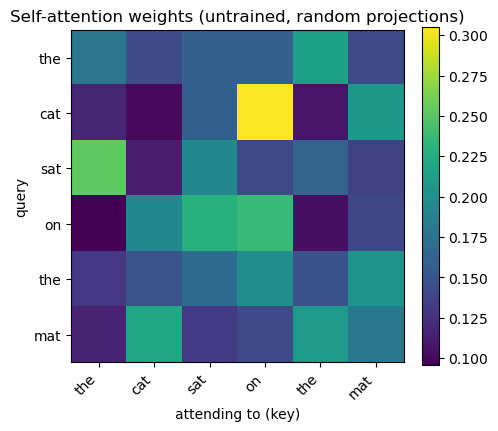

In [12]:
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(attn_weights[0].detach().numpy(), cmap="viridis")
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
ax.set_xlabel("attending to (key)"); ax.set_ylabel("query")
ax.set_title("Self-attention weights (untrained, random projections)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(f"{FIGS}/day11-attention-heatmap.png", dpi=130)
plt.show()

Every row is a probability distribution over which other tokens that query attends to. Right now the pattern is meaningless (random weights) — after training on real data, these weights learn to track genuine linguistic or biological relationships (e.g. a verb attending to its subject, or in AlphaFold's Evoformer, a residue attending to residues it co-evolves with — see the case study below).

## The causal mask: from BERT to GPT

## 4) Causal masking: the GPT difference

Everything above lets every position attend to every other position — fine for an *encoder* that sees a whole sentence (or a whole protein) at once. A **decoder-only** model like GPT generates one token at a time and must never be allowed to peek at tokens it hasn\'t generated yet. The fix is a **causal mask**: before the softmax, set every "attend to the future" score to $-\infty$, so it becomes exactly 0 after softmax.

Row 0 (token 'the') can attend to: [1. 0. 0. 0. 0. 0.]
Row 5 (token 'mat') can attend to: [0.116 0.22  0.131 0.144 0.208 0.18 ]

Weight assigned to any FUTURE position (should be exactly 0.0): 0.0


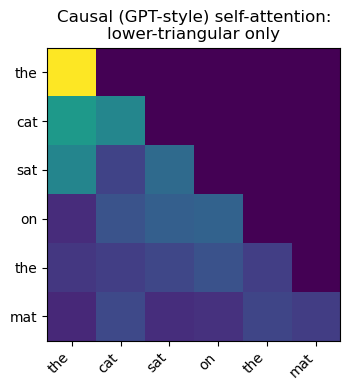

In [13]:
def causal_mask(n):
    mask = torch.triu(torch.ones(n, n), diagonal=1).bool()  # True above the diagonal = "future"
    return mask


def masked_scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights


mask = causal_mask(n)
_, causal_weights = masked_scaled_dot_product_attention(Q, K, V, mask=mask)

print("Row 0 (token 'the') can attend to:", causal_weights[0, 0].detach().numpy().round(3))
print("Row 5 (token 'mat') can attend to:", causal_weights[0, 5].detach().numpy().round(3))
print()
print("Weight assigned to any FUTURE position (should be exactly 0.0):",
      float(causal_weights[0][mask].abs().max()))

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(causal_weights[0].detach().numpy(), cmap="viridis")
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
ax.set_title("Causal (GPT-style) self-attention:\nlower-triangular only")
plt.tight_layout()
plt.savefig(f"{FIGS}/day11-causal-mask.png", dpi=130)
plt.show()

The first token can only attend to itself; the last token can attend to everything before and including itself. This one masking change — nothing else — is the entire architectural difference between an encoder (Day 12\'s attention section above, and AlphaFold\'s Evoformer, which sees a whole sequence/alignment at once) and a GPT-style decoder (which must generate left-to-right). Stack many causal self-attention layers, train by next-token prediction on a huge unlabeled corpus, and that *is* a GPT model — the same self-supervised idea as Day 11\'s UniRep (next amino acid, on an LSTM), now with attention instead of recurrence, at a much larger scale.

## A real protein language model fills in the blanks

**ESM-2** (Lin et al., 2023) is a BERT-style Transformer: during training,
15% of the residues are masked and the model predicts them from the rest
of the sequence. We mask one residue in the hydrophobic core of a real
signal peptide and ask the model what belongs there, then do the same
for a residue in a cytoplasmic protein.

In [14]:
import esm
esm_model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()      # 35M parameters; t6_8M is smaller and faster
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
ESM_LAYER = esm_model.num_layers

def masked_prediction(seq, pos, top=5):
    '''Mask residue `pos` (0-based) and return ESM-2's top predictions.'''
    _, _, tokens = batch_converter([("q", seq)])
    tokens[0, pos + 1] = alphabet.mask_idx                     # +1: the BOS token comes first
    with torch.no_grad():
        logits = esm_model(tokens.to(device))["logits"][0, pos + 1]
    aa_ids = [alphabet.get_idx(a) for a in AA]
    p = torch.softmax(logits[aa_ids], 0).cpu().numpy()
    order = np.argsort(-p)[:top]
    return [(AA[k], round(float(p[k]), 3)) for k in order]

sp_row = table[(table.group == "euk_sp") & (table.sp_end >= 20)].iloc[0]
cyt_row = table[table.group == "euk_cyt"].iloc[0]
h_pos = 10                                                      # inside the h-region of most signal peptides
print(f"{sp_row.accession} (signal peptide 1-{sp_row.sp_end}): {sp_row.sequence[:40]}...")
print(f"  masked residue {h_pos + 1} (true: {sp_row.sequence[h_pos]}) -> ESM-2 predicts", masked_prediction(sp_row.sequence, h_pos))
print(f"{cyt_row.accession} (cytoplasmic/nuclear): {cyt_row.sequence[:40]}...")
print(f"  masked residue {h_pos + 1} (true: {cyt_row.sequence[h_pos]}) -> ESM-2 predicts", masked_prediction(cyt_row.sequence, h_pos))

P04651 (signal peptide 1-20): MEMFQGLLLWLLLGVAGVWASRGPLRPLCQPINATLAAEK...
  masked residue 11 (true: L) -> ESM-2 predicts [('L', 0.409), ('A', 0.155), ('V', 0.121), ('G', 0.095), ('S', 0.04)]
A9UHW6 (cytoplasmic/nuclear): MGEPSREEYKIQSFDAETQQLLKTALKDPGAVDLEKVANV...
  masked residue 11 (true: I) -> ESM-2 predicts [('L', 0.102), ('R', 0.097), ('A', 0.088), ('K', 0.087), ('Q', 0.078)]


Without ever being told what a signal peptide is, the model expects a
hydrophobic residue in the middle of one, and something different in a
cytoplasmic protein at the same position. That context-dependent
knowledge is what its internal representations (embeddings) carry.

# Part 3 — SignalP 6.0's idea, at classroom scale

SignalP 6.0 (Teufel et al., 2022) replaced hand-designed input with a
pretrained protein language model (ProtBERT). Its authors report two
effects: **few-shot learning** (signal-peptide types with only 36 and 113
known examples became predictable) and **better generalization** to
proteins unlike the training set. We test both claims with a much
smaller language model (ESM-2, 35M parameters) used as a frozen feature
extractor, on a simpler task: does a protein have a signal peptide?

Features, all from the first 70 residues:

- **one-hot**: 70 × 20 = 1,400 numbers;
- **ESM-2 embedding**: the model's last-layer vectors for the 70
  residues, averaged into 480 numbers.

In [15]:
N70 = 70
onehot = np.zeros((len(sequences), N70 * 20), dtype=np.float32)
for n, s in enumerate(sequences):
    for p, ch in enumerate(s[:N70]):
        onehot[n, p * 20 + aa_to_idx[ch]] = 1.0

embeddings = []
with torch.no_grad():
    for b in range(0, len(sequences), 32):
        _, _, tok = batch_converter([(str(i), s[:N70]) for i, s in enumerate(sequences[b:b + 32])])
        rep = esm_model(tok.to(device), repr_layers=[ESM_LAYER])["representations"][ESM_LAYER]
        embeddings.append(rep[:, 1:N70 + 1].mean(1).cpu().numpy())
embeddings = np.concatenate(embeddings)
print("one-hot:", onehot.shape, "  ESM-2:", embeddings.shape)

one-hot: (4910, 1400)   ESM-2: (4910, 480)


Three classifiers: logistic regression on one-hot, a small 1D CNN on
one-hot (Day 10; closer to the pre-language-model era of SignalP 5.0),
and logistic regression on the frozen ESM-2 embeddings (transfer learning,
exactly like the ImageNet ResNet on Day 10).

In [16]:
X_seq = torch.tensor(onehot.reshape(-1, N70, 20).transpose(0, 2, 1).copy())

def fit_logreg(X, train_idx):
    return LogisticRegression(max_iter=3000).fit(X[train_idx], has_sp[train_idx])

def fit_cnn(train_idx, epochs=60, seed=0):
    torch.manual_seed(seed)
    m = nn.Sequential(nn.Conv1d(20, 32, 9, padding=4), nn.ReLU(), nn.Conv1d(32, 32, 9, padding=4), nn.ReLU(),
                      nn.AdaptiveMaxPool1d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(32, 2)).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    Xs, ys = X_seq[train_idx].to(device), torch.tensor(has_sp[train_idx]).to(device)
    steps = max(epochs, int(epochs * 3000 / len(train_idx) / 4))     # small training sets get more epochs
    for _ in range(steps):
        m.train()
        for b in torch.randperm(len(train_idx)).split(64):
            opt.zero_grad(); nn.functional.cross_entropy(m(Xs[b]), ys[b]).backward(); opt.step()
    return m.eval()

def predict(model, kind, idx):
    if kind == "cnn":
        with torch.no_grad():
            return model(X_seq[idx].to(device)).argmax(1).cpu().numpy()
    X = onehot if kind == "onehot" else embeddings
    return model.predict(X[idx])

def train_all(train_idx):
    return {"one-hot + logistic regression": (fit_logreg(onehot, train_idx), "onehot"),
            "one-hot + 1D CNN": (fit_cnn(train_idx), "cnn"),
            "ESM-2 embedding + logistic regression": (fit_logreg(embeddings, train_idx), "esm")}

trainval = np.concatenate([tr_i, va_i])
models = train_all(trainval)
print("homology-aware split, test set used once:")
for name, (m, kind) in models.items():
    p = predict(m, kind, te_i)
    print(f"  {name:40s} MCC {matthews_corrcoef(has_sp[te_i], p):.3f}   accuracy {(p == has_sp[te_i]).mean():.3f}")

homology-aware split, test set used once:
  one-hot + logistic regression            MCC 0.745   accuracy 0.879
  one-hot + 1D CNN                         MCC 0.837   accuracy 0.922
  ESM-2 embedding + logistic regression    MCC 0.955   accuracy 0.978


### Few-shot: how much labelled data does each approach need?

Train on random subsets of the training proteins, from 20 to all of them,
and score each on the same homology-aware test set:

n =    20: one-hot 0.045  one-hot CNN 0.114  ESM-2 embedding 0.762


n =    50: one-hot 0.433  one-hot CNN 0.450  ESM-2 embedding 0.907


n =   100: one-hot 0.517  one-hot CNN 0.517  ESM-2 embedding 0.913


n =   300: one-hot 0.690  one-hot CNN 0.678  ESM-2 embedding 0.932


n =  1000: one-hot 0.734  one-hot CNN 0.762  ESM-2 embedding 0.941


n =  4169: one-hot 0.745  one-hot CNN 0.839  ESM-2 embedding 0.955


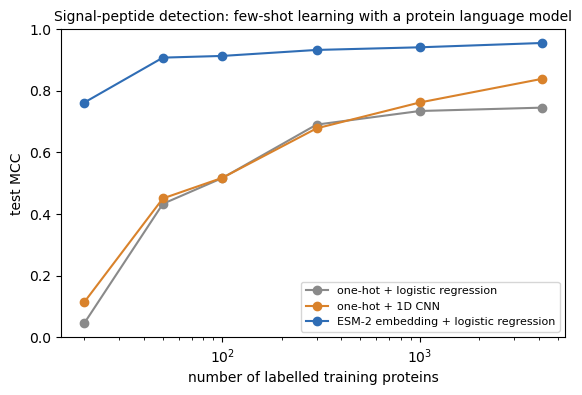

In [17]:
sizes = [20, 50, 100, 300, 1000, len(trainval)]
curve = {name: [] for name in models}
for n in sizes:
    sub = np.random.RandomState(1).choice(trainval, n, replace=False)
    for name, (m, kind) in train_all(sub).items():
        curve[name].append(matthews_corrcoef(has_sp[te_i], predict(m, kind, te_i)))
    print(f"n = {n:5d}: " + "  ".join(f"{name.split(' +')[0]}{' CNN' if 'CNN' in name else ''} {curve[name][-1]:.3f}"
                                     for name in models))

plt.figure(figsize=(6.5, 4))
for (name, vals), c in zip(curve.items(), ["#8a8a8a", "#d9822b", "#2f6db5"]):
    plt.plot(sizes, vals, "o-", color=c, label=name)
plt.xscale("log"); plt.ylim(0, 1)
plt.xlabel("number of labelled training proteins"); plt.ylabel("test MCC")
plt.title("Signal-peptide detection: few-shot learning with a protein language model", fontsize=10)
plt.legend(fontsize=8)
plt.savefig(f"{FIGS}/day11-fewshot.png", dpi=150, bbox_inches="tight"); plt.show()

### Generalization: does it matter how similar a test protein is to the training set?

SignalP 6.0's authors measured this on proteins removed during homology
partitioning. Here: a plain *random* 80/20 split (so the test set covers
the whole range), with each test protein's identity to its most similar
training protein from an MMseqs2 search (precomputed; 0 means no hit).

identity <30%    n =  441: 0.681  0.776  0.960
identity 30-50%  n =  288: 0.734  0.728  0.985
identity 50-70%  n =  122: 0.696  0.948  0.965
identity 70-90%  n =   78: 0.786  0.764  0.971
identity >90%    n =   53: 1.000  1.000  1.000


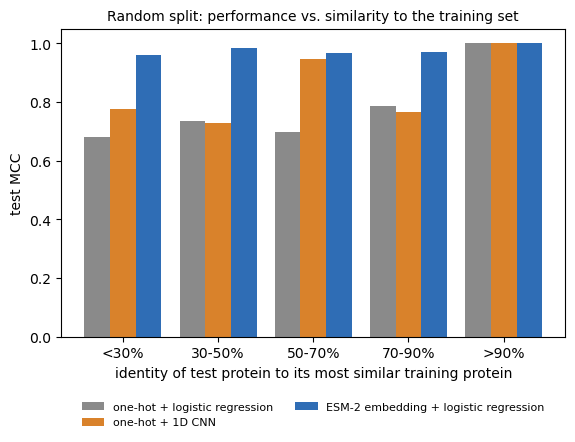

In [18]:
perm = np.random.RandomState(0).permutation(len(sequences))
rte, rtr = perm[:len(perm) // 5], perm[len(perm) // 5:]
ident = pd.read_csv(io.StringIO(course_file("day11-random-split-identity.tsv")), sep="\t")
ident = dict(zip(ident.accession, ident.max_identity_to_train))
test_ident = np.array([ident[a] for a in table.accession.iloc[rte]])
bins = [(0, 0.3, "<30%"), (0.3, 0.5, "30-50%"), (0.5, 0.7, "50-70%"), (0.7, 0.9, "70-90%"), (0.9, 1.01, ">90%")]
rmodels = train_all(rtr)
by_bin = {name: [] for name in rmodels}
for lo, hi, lab in bins:
    sel = rte[(test_ident >= lo) & (test_ident < hi)]
    row = []
    for name, (m, kind) in rmodels.items():
        by_bin[name].append(matthews_corrcoef(has_sp[sel], predict(m, kind, sel)))
    print(f"identity {lab:7s} n = {len(sel):4d}: " + "  ".join(f"{by_bin[n][-1]:.3f}" for n in rmodels))

plt.figure(figsize=(6.5, 4))
xs = np.arange(len(bins))
for k, ((name, vals), c) in enumerate(zip(by_bin.items(), ["#8a8a8a", "#d9822b", "#2f6db5"])):
    plt.bar(xs + (k - 1) * 0.27, vals, width=0.27, color=c, label=name)
plt.xticks(xs, [b[2] for b in bins]); plt.ylim(0, 1.05)
plt.xlabel("identity of test protein to its most similar training protein"); plt.ylabel("test MCC")
plt.title("Random split: performance vs. similarity to the training set", fontsize=10)
plt.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.savefig(f"{FIGS}/day11-identity-bins.png", dpi=150, bbox_inches="tight"); plt.show()

### What do the embeddings look like?

A two-dimensional PCA projection of the 480-number ESM-2 embeddings,
coloured by group. Nothing in the language model's training used these
labels.

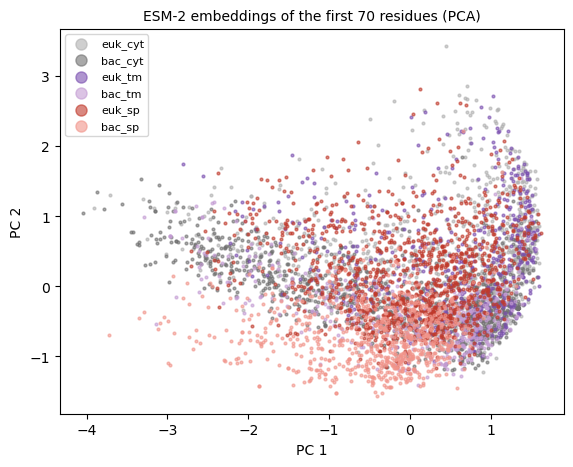

In [19]:
from sklearn.decomposition import PCA
xy = PCA(n_components=2, random_state=0).fit_transform(embeddings)
plt.figure(figsize=(6.5, 5))
for g, c in [("euk_cyt", "#b0b0b0"), ("bac_cyt", "#707070"), ("euk_tm", "#7a4fb0"), ("bac_tm", "#c39bd3"),
             ("euk_sp", "#c0392b"), ("bac_sp", "#f1948a")]:
    m = (table.group == g).to_numpy()
    plt.scatter(*xy[m].T, s=4, color=c, label=g, alpha=0.6)
plt.legend(markerscale=4, fontsize=8); plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.title("ESM-2 embeddings of the first 70 residues (PCA)", fontsize=10)
plt.savefig(f"{FIGS}/day11-esm-pca.png", dpi=150, bbox_inches="tight"); plt.show()

## Try it yourself

- Swap in the smaller `esm2_t6_8M_UR50D` (8M parameters). How much of the
  few-shot advantage survives?
- Use only the first 30 residues for every feature set. Which approach
  suffers most?
- In Part 1, add a 1D convolution before the BiLSTM (the SignalP 5.0
  recipe). Does the residue-level MCC improve?